# Gaia DR4 pre-release

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from exogaia.data import GaiaAstrometry
from exogaia.leastsq import LeastSquares

In [3]:
source_id = 1457486023639239296  # Gaia-4
primary_mass = (0.644, 0.025)  # (Msun)

In [4]:
epoch_astrom = GaiaAstrometry(primary_mass=primary_mass, gaia_release="DR4", verbose=True)
epoch_astrom.retrieve_dr4_prelease(source_id=source_id, exclude_outliers=True, combine_ccds=True)


Gaia astrometry

Gaia release: DR4
Reference epoch: J2017.500

Primary mass (Msun): 0.64 +/- 0.03

---------------
Querying source
---------------

Gaia release: DR3
Source ID: 1457486023639239296

INFO: Query finished. [astroquery.utils.tap.core]

RA = 209.506 deg +/- 0.013 mas
Dec = 31.695 deg +/- 0.013 mas
Parallax = 13.545 +/- 0.021 mas
Proper motion in RA = -75.412 +/- 0.020 mas/yr
Proper motion in Dec = 18.063 +/- 0.016 mas/yr
G-band magnitude = 11.909
Pseudocolor = 1.39 um-1

UWE = 1.97
RUWE = 1.50
Astrometric excess noise (mas) = 0.1563 +/- 0.0045
Non single star = 1

---------------------------
Retrieving epoch astrometry
---------------------------

Gaia release: DR4
Reference epoch: J2017.500
Source ID: 1457486023639239296

Primary mass (Msun): 0.64 +/- 0.03

Data file: /Users/tomasstolker/.exogaia/GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml
Data shape: (1008, 37)

Number of rows for selected source:
   - Total = 1150
   - Selected = 824


In [5]:
epoch_astrom.data_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   solution_id                93 non-null     Int64  
 1   source_id                  93 non-null     Int64  
 2   transit_id                 93 non-null     Int64  
 3   ra0                        93 non-null     Float64
 4   dec0                       93 non-null     Float64
 5   agis_source_excess_noise   93 non-null     Float32
 6   obs_time_tcb               93 non-null     float64
 7   obs_time_bary_corr         93 non-null     Int64  
 8   scan_pos_angle             93 non-null     Float64
 9   zeta                       93 non-null     Float32
 10  parallax_factor_al         93 non-null     Float32
 11  parallax_factor_ac         93 non-null     Float32
 12  colour_factor_al           93 non-null     Float64
 13  colour_factor_ac           93 non-null     Float64
 14  nu_eff_

In [6]:
leastsq = LeastSquares(epoch_astrometry=epoch_astrom)


--------------------------
Orbit grid (12-parameters)
--------------------------



  0%|          | 0/900 [00:00<?, ?it/s]


Best-fit RUWE = 1.843

Best-fit stellar track:
   - RA offset (mas) = -0.031 +/- 0.008
   - Dec offset (mas) = 0.107 +/- 0.009
   - Parallax (mas) = 13.659 +/- 0.010
   - mu in RA (mas/yr) = -75.533 +/- 0.005
   - mu in Dec (mas/yr) = 17.957 +/- 0.005

Best-fit orbit:
   - Period (days) = 528.966
   - Eccentricity = 0.267
   - Relative time of periastron = 0.90
   - Thiele-Innes A = 0.221 +/- 0.011
   - Thiele-Innes B = 0.018 +/- 0.010
   - Thiele-Innes F = 0.101 +/- 0.010
   - Thiele-Innes G = -0.092 +/- 0.009

Derived parameters:
   - Semi-major axis of photocenter (mas) = 0.244 +/- 0.011
   - Relative semi-major axis (au) = 1.111
   - Mass function (Msun) = 2.712e-06
   - Companion mass (Msun) = 1.051e-02

Conversion to Campbell elements:
   - Period = 528.966 days
   - Eccentricity = 0.267
   - Relative time of periastron = 0.900
   - Semi-major axis of photocenter (mas) = 0.244
   - Inclination (deg) = 111.734
   - Argument of periastron (deg) = 153.163
   - PA of ascending node 

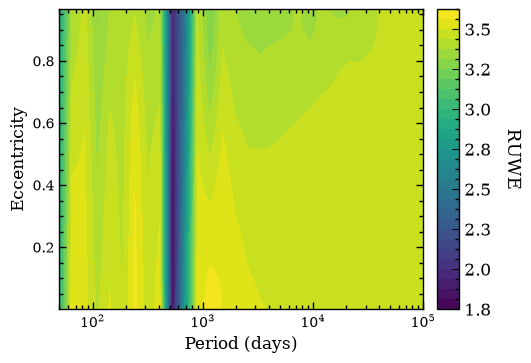

In [7]:
fig = leastsq.orbit_grid(map_type='ruwe', plot_file='plot.png', n_points=30)


-------------------------
Orbit fit (12 parameters)
-------------------------

Reduced chi^2: 1.719
RUWE: 0.997

Best-fit stellar track:
   - RA offset (mas) = -0.041 +/- 0.013
   - Dec offset (mas) = 0.129 +/- 0.019
   - Parallax (mas) = 13.629 +/- 0.007
   - mu in RA (mas/yr) = -75.532 +/- 0.003
   - mu in Dec (mas/yr) = 17.966 +/- 0.003

Best-fit orbit:
   - Period (days) = 573.087 +/- 2.673
   - Eccentricity = 0.295 +/- 0.050
   - Relative time of periastron = 1.000 +/- 0.029
   - Semi-major axis of photocenter (mas) = 0.247 +/- 0.007
   - Inclination (deg) = 122.355 +/- 2.272
   - Argument of periastron (deg) = 180.410 +/- 10.870
   - PA of ascending node (deg) = 173.516 +/- 2.217

Number of function evaluations: 9
Number of Jacobian evaluations: 9

Derived parameters:
   - Relative semi-major axis (au) = 1.172
   - Mass function (Msun) = 2.411e-06
   - Companion mass (Msun) = 1.010e-02


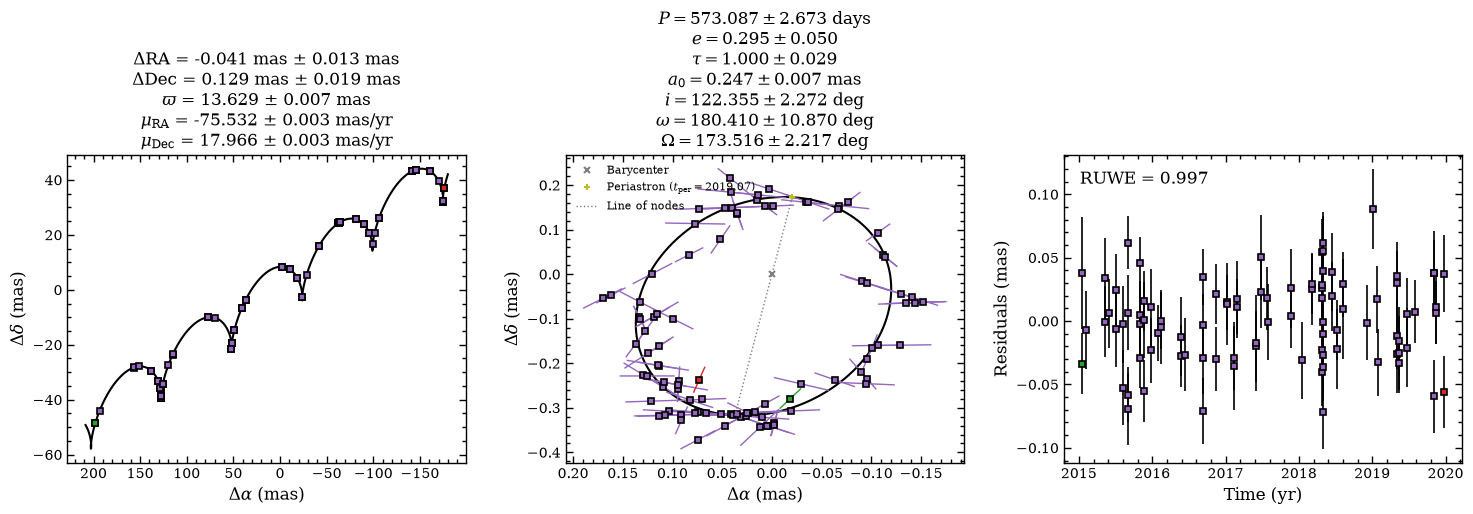

In [8]:
fig = leastsq.orbit_fit(inc_jitter=False, plot_file='plot.png')

In [9]:
print(leastsq)

LeastSquares(Δα = -0.040749 mas, Δδ = 0.129385 mas, ϖ = 13.6287 mas, μ_α = -75.5319 mas/yr, μ_δ = 17.9662 mas/yr, P = 573.087 days, e = 0.294848, τ = 1, a = 0.246776 mas, i = 2.1355 rad, ω = 3.14875 rad, Ω = 3.02842 rad)
